In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# load data
X, y = [], []
for file in os.listdir("../preprocessed_data"):
    if file.endswith(".npy"):
        label = int(file.split("_")[3])  # from e.g. ..._label_0_stripped.npy
        vol = np.load(os.path.join("../preprocessed_data", file))  # shape: (1, D, H, W)
        X.append(vol)
        y.append(label)

# horizontal flip along width axis (W = axis 3)
X_aug = []
y_aug = []
for i in range(len(X)):
    flipped = np.flip(X[i], axis=3)
    X_aug.append(flipped)
    y_aug.append(y[i])

X = np.concatenate([X, np.array(X_aug)])
y = np.concatenate([y, np.array(y_aug)])

# flip vertically (height axis)
X_flip_v = [np.flip(x, axis=2) for x in X]
y_flip_v = y.copy()

# add Gaussian noise
X_noise = [x + np.random.normal(0, 0.01, x.shape) for x in X]
y_noise = y.copy()

# merge all
X = np.concatenate([X, np.array(X_flip_v), np.array(X_noise)])
y = np.concatenate([y, np.array(y_flip_v), np.array(y_noise)])

X = np.array(X)
y = np.array(y)

# normalize
X = (X - np.mean(X)) / np.std(X)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# sample weights
class_sample_count = np.array([np.sum(y_train == t) for t in np.unique(y_train)])
weights = 1. / class_sample_count
sample_weights = weights[y_train]  # assign weight to each sample
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)


# dataloader
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=2,
    sampler=sampler  # no shuffle needed
)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=2)

# 3D CNN (5 layer)
class Deeper3DCNN(nn.Module):
    def __init__(self, dropout=0.5):
        super(Deeper3DCNN, self).__init__()
        self.conv1 = nn.Conv3d(1, 4, 3, padding=1)
        self.bn1 = nn.BatchNorm3d(4)

        self.conv2 = nn.Conv3d(4, 8, 3, padding=1)
        self.bn2 = nn.BatchNorm3d(8)

        self.conv3 = nn.Conv3d(8, 16, 3, padding=1)
        self.bn3 = nn.BatchNorm3d(16)

        self.conv4 = nn.Conv3d(16, 32, 3, padding=1)
        self.bn4 = nn.BatchNorm3d(32)

        self.conv5 = nn.Conv3d(32, 64, 3, padding=1)
        self.bn5 = nn.BatchNorm3d(64)

        self.pool = nn.MaxPool3d(2)
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(64 * 2 * 4 * 4, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        x = self.pool(torch.relu(self.bn5(self.conv5(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

# setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Deeper3DCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_and_evaluate(lr, batch_size, dropout_rate, epochs):
    model = Deeper3DCNN(dropout=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # recreate dataloader
    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=batch_size,
        sampler=sampler
    )
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size)

    # train the model
    train_loss = []
    train_acc = []
    test_acc = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train, total_train = 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        # Each epoch records the average loss and accuracy of the training set
        train_loss.append(running_loss / len(train_loader))
        train_acc.append(correct_train / total_train)

        model.eval()
        correct_test, total_test = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                correct_test += (predicted.cpu() == labels).sum().item()
                total_test += labels.size(0)
        acc = correct_test / total_test
        test_acc.append(acc)

    return train_loss, train_acc, test_acc

# hyperparameter tuning
larning_rate_list = [1e-4]
batch_list = [16]
dropout_list = [0.5]
epochs = 20

# find the group of hyperparameters
for lr in larning_rate_list:
    for batch in batch_list:
        for dropout in dropout_list:
            train_loss, train_acc, test_acc = train_and_evaluate(lr, batch, dropout, epochs)

            plt.plot(range(1, epochs+1), train_loss, label='Training Loss')
            plt.plot(range(1, epochs+1), train_acc, label='Training Accuracy')
            plt.plot(range(1, epochs+1), test_acc, label='Test Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Value')
            plt.title(f'Training Loss, Train Accuracy, Test Accuracy per Epoch\n(lr={lr}, batch={batch}, dropout={dropout})')
            plt.legend()
            plt.show()

            final_acc = test_acc[-1]
            print(f"lr={lr}, batch={batch}, dropout={dropout} -> acc={final_acc:.2%}")

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [2]:
# 1.load data and notice the label
# 2.Data augmentation: horizontal flip, vertical flip, Gaussian noise
X, y = [], []
for file in os.listdir("../preprocessed_data"):
    if file.endswith(".npy"):
        label = int(file.split("_")[3])
        vol = np.load(os.path.join("../preprocessed_data", file))
        X.append(vol)
        y.append(label)

# horizontal flip
X_aug = []
y_aug = []
for i in range(len(X)):
    flipped = np.flip(X[i], axis=3)
    X_aug.append(flipped)
    y_aug.append(y[i])

# vertical flip
X = np.concatenate([X, np.array(X_aug)])
y = np.concatenate([y, np.array(y_aug)])
X_flip_v = [np.flip(x, axis=2) for x in X]
y_flip_v = y.copy()

# Gaussian noise
X_noise = [x + np.random.normal(0, 0.01, x.shape) for x in X]
y_noise = y.copy()
X = np.concatenate([X, np.array(X_flip_v), np.array(X_noise)])
y = np.concatenate([y, np.array(y_flip_v), np.array(y_noise)])

In [3]:
# Normalization and split into training and test sets
X = np.array(X)
y = np.array(y)
X = (X - np.mean(X)) / np.std(X)

# train:80%, test:20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [4]:
# Convert NumPy data to PyTorch tensors
# Convert the feature matrices in the training and test sets from NumPy to PyTorch tensors of 32-bit floating point numbers (float32), which is a common data type for CNN input.The labels are also converted to tensors, specifying the data type as long (int64), which is the type required by CrossEntropyLoss().
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Design a sampler for class imbalance, count the number of samples for each class, calculate and assign weights, and create a weighted sampler
class_sample_count = np.array([np.sum(y_train == t) for t in np.unique(y_train)])
weights = 1. / class_sample_count
sample_weights = weights[y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)


In [6]:
# 5-layer 3D CNN model structure, constructing a 5-layer 3D convolutional network with BatchNorm and Dropout for volumetric MRI data classification.
class Deeper3DCNN(nn.Module):
    def __init__(self, dropout=0.5):
        super(Deeper3DCNN, self).__init__()
        self.conv1 = nn.Conv3d(1, 4, 3, padding=1)
        self.bn1 = nn.BatchNorm3d(4)
        self.conv2 = nn.Conv3d(4, 8, 3, padding=1)
        self.bn2 = nn.BatchNorm3d(8)
        self.conv3 = nn.Conv3d(8, 16, 3, padding=1)
        self.bn3 = nn.BatchNorm3d(16)
        self.conv4 = nn.Conv3d(16, 32, 3, padding=1)
        self.bn4 = nn.BatchNorm3d(32)
        self.conv5 = nn.Conv3d(32, 64, 3, padding=1)
        self.bn5 = nn.BatchNorm3d(64)

        self.pool = nn.MaxPool3d(2)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64 * 2 * 4 * 4, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        x = self.pool(torch.relu(self.bn5(self.conv5(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

In [9]:
# Define training and evaluation functions
# lr: learning rate;batch_size; number of samples in each mini-batch; dropout_rate: dropout rate, used to prevent overfitting; epochs: number of training rounds
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_and_evaluate(lr, batch_size, dropout_rate, epochs):
    model = Deeper3DCNN(dropout=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Create a DataLoader using dynamic batch size, in hyperparameter tuning
    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=batch_size,
        sampler=sampler
    )
    test_loader = DataLoader(
        TensorDataset(X_test_tensor, y_test_tensor),
        batch_size=batch_size)

    # Initialize storage list
    train_loss = []
    train_acc = []
    test_acc = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train, total_train = 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss.append(running_loss / len(train_loader))
        train_acc.append(correct_train / total_train)

        model.eval()
        correct_test, total_test = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                correct_test += (predicted.cpu() == labels).sum().item()
                total_test += labels.size(0)
        acc = correct_test / total_test
        test_acc.append(acc)

    return train_loss, train_acc, test_acc

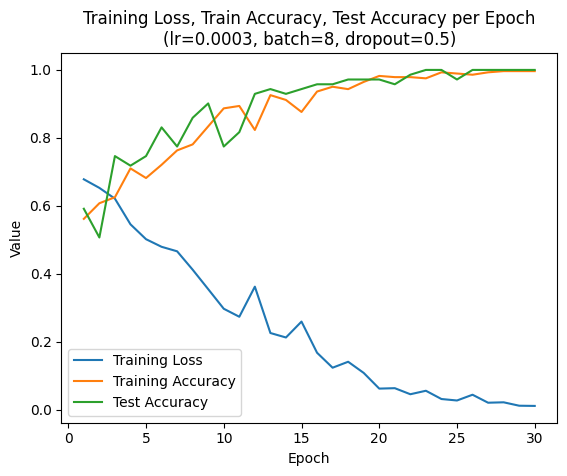

lr=0.0003, batch=8, dropout=0.5 -> acc=100.00%


In [12]:
# define the hyperparameter, draw the plot of train, test, loss. create a confusion matrix
# hyperparameter tuning preparation
larning_rate_list = [3e-4]
batch_list = [8]
dropout_list = [0.5]
epochs = 30

for lr in larning_rate_list:
    for batch in batch_list:
        for dropout in dropout_list:
            train_loss, train_acc, test_acc = train_and_evaluate(lr, batch, dropout, epochs)

            plt.plot(range(1, epochs+1), train_loss, label='Training Loss')
            plt.plot(range(1, epochs+1), train_acc, label='Training Accuracy')
            plt.plot(range(1, epochs+1), test_acc, label='Test Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Value')
            plt.title(f'Training Loss, Train Accuracy, Test Accuracy per Epoch\n(lr={lr}, batch={batch}, dropout={dropout})')
            plt.legend()
            plt.show()

            final_acc = test_acc[-1]
            print(f"lr={lr}, batch={batch}, dropout={dropout} -> acc={final_acc:.2%}")
